# Etapa 1: base Kaggle e Análise Exploratória

**Datathon POSTECH — Machine Learning Engineering (Fase 5)**

Base utilizada: [Bank Marketing, de henriqueyamahata](https://www.kaggle.com/datasets/henriqueyamahata/bank-marketing),
arquivo `bank-additional-full.csv`. A origem primária é o UCI Machine Learning
Repository (Moro, Cortez e Rita, 2014).

O problema tratado aqui é uma decisão repetida: para cada cliente elegível, de
que forma a instituição deve fazer o contato. Cada forma possível de contato é
chamada de **braço**. O algoritmo que escolhe um braço, observa o resultado e
usa esse resultado para melhorar as escolhas seguintes é chamado de **bandit**.
Quando a escolha leva em conta características do cliente, o bandit é
**contextual**.

Este notebook cumpre a Etapa 1 do enunciado e responde a três perguntas, nesta
ordem:

1. o que a base contém e quais colunas podem ser usadas na decisão;
2. qual é a decisão que está sendo modelada, ou seja, quais são os braços
   disponíveis;
3. se existe sinal contextual, isto é, se o melhor braço muda conforme o cliente
   ou se uma única regra atende bem a todos.

A resposta à terceira pergunta determina se um bandit contextual se justifica ou
se ele apenas acrescenta complexidade ao projeto. Por esse motivo, ela é
investigada antes de qualquer modelagem.

In [1]:
import sys, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)
sns.set_theme(style="whitegrid", palette="deep")

from adaptive_offers.config import ARMS, CONTEXT_FEATURES, LEAKAGE_COLUMNS, MACRO_COLUMNS
from adaptive_offers.data.download import load_raw

## 1. Carga da base

O download é feito em duas tentativas. O notebook procura primeiro a base no
Kaggle, por meio da biblioteca `kagglehub`, o que exige credenciais configuradas
na máquina. Quando essas credenciais não existem, a base é obtida no espelho
público da UCI. As duas fontes fornecem o mesmo arquivo, de modo que o notebook
pode ser executado em qualquer máquina, com ou sem conta no Kaggle.

In [2]:
raw = load_raw()
print(f"Dimensões: {raw.shape[0]:,} linhas x {raw.shape[1]} colunas".replace(",", "."))
raw.head()

Dimensões: 41.188 linhas x 21 colunas


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
resumo = pd.DataFrame({
    "tipo": raw.dtypes.astype(str),
    "nulos": raw.isna().sum(),
    "valores_unicos": raw.nunique(),
})
resumo

,tipo,nulos,valores_unicos
age,int64,0,78
job,object,0,12
marital,object,0,4
education,object,0,8
default,object,0,3
housing,object,0,3
loan,object,0,3
contact,object,0,2
month,object,0,10
day_of_week,object,0,5


Não há valores nulos no sentido do pandas, ou seja, nenhuma célula está vazia.
Isso não significa que a base esteja limpa: a falta de informação foi registrada
pelo texto `"unknown"`. Esse valor precisa ser tratado como uma categoria à
parte e não pode ser confundido com uma informação efetivamente observada.

In [4]:
categoricas = raw.select_dtypes(include="object").columns
desconhecidos = {c: (raw[c] == "unknown").mean() for c in categoricas}
pd.Series(desconhecidos).sort_values(ascending=False).mul(100).round(2).to_frame("% unknown")

,% unknown
default,20.87
education,4.20
housing,2.40
loan,2.40
job,0.80
marital,0.19
contact,0.00
month,0.00
day_of_week,0.00
poutcome,0.00


## 2. A variável-alvo

A coluna `y` indica se o cliente assinou ou não o depósito a prazo. Ela é a
**recompensa** do bandit, isto é, o retorno que o algoritmo observa depois de
escolher um braço. Como esse retorno é binário e já está registrado na base, não
é necessário gerar dados sintéticos de conversão, alternativa permitida pela
Etapa 2 do enunciado.

In [5]:
raw["reward"] = (raw["y"] == "yes").astype(int)
taxa = raw["reward"].mean()
print(f"Conversão global: {taxa:.2%}")
print(f"Positivos: {raw['reward'].sum():,}  |  Negativos: {(1 - raw['reward']).sum():,}".replace(",", "."))

Conversão global: 11.27%
Positivos: 4.640  |  Negativos: 36.548


Cerca de 11% dos contatos resultam em conversão, o que caracteriza uma base
desbalanceada. Esse desbalanceamento tem efeito direto sobre o projeto do
bandit: como a conversão é rara, cada braço precisa de centenas de observações
até que sua taxa possa ser distinguida com segurança da taxa dos demais. Em
consequência, a quantidade de contatos disponíveis no experimento pesa mais
sobre a velocidade de aprendizado do que a escolha do algoritmo. Esse ponto é
retomado no notebook 02.

## 3. Vazamento temporal: por que `duration` precisa ser descartada

A coluna `duration` registra quantos segundos durou a ligação. A documentação da
própria base adverte que esse valor só é conhecido depois que a ligação termina
e que uma ligação de duração zero corresponde sempre a `y = "no"`.

A decisão modelada neste trabalho é tomada antes de o cliente ser contatado.
Usar `duration` significaria, portanto, empregar uma informação que ainda não
existe no momento da decisão. Esse erro é chamado de vazamento temporal. A
célula abaixo mede o seu tamanho.

Correlação de duration com a conversão: 0.405

       count   mean    50%     max
y                                 
no   36548.0  220.8  163.5  4918.0
yes   4640.0  553.2  449.0  4199.0


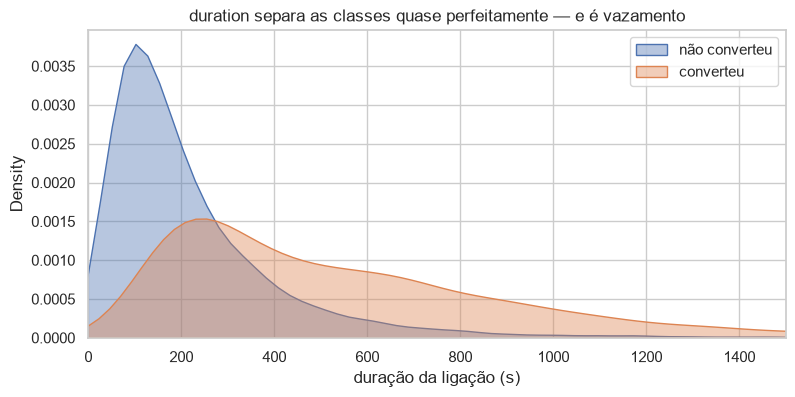


Descartada do contexto: ['duration']


In [6]:
print("Correlação de duration com a conversão:", raw["duration"].corr(raw["reward"]).round(3))
print()
print(raw.groupby("y")["duration"].describe()[["count", "mean", "50%", "max"]].round(1))

fig, ax = plt.subplots(figsize=(9, 4))
for valor, rotulo in [(0, "não converteu"), (1, "converteu")]:
    sns.kdeplot(raw.loc[raw["reward"] == valor, "duration"], label=rotulo, fill=True, alpha=0.4, ax=ax)
ax.set_xlim(0, 1500)
ax.set_xlabel("duração da ligação (s)"); ax.set_title("duration separa as classes quase perfeitamente — e é vazamento")
ax.legend(); plt.show()

print(f"\nDescartada do contexto: {LEAKAGE_COLUMNS}")

As distribuições das duas classes quase não se sobrepõem: a duração da ligação
praticamente revela o resultado. Um modelo treinado com `duration` apresentaria
métricas excelentes e seria inútil em produção, porque esse valor ainda não
existe quando a decisão precisa ser tomada. Descartar a coluna reduz as métricas
aparentes e é a decisão metodologicamente correta.

## 4. O espaço de ações: definição do braço

A base trata de um único produto, o depósito a prazo. A decisão, portanto, não é
qual produto oferecer. O que a instituição de fato escolhe, e que está
registrado na base, é a forma da abordagem:

| Coluna | Papel na decisão | Valores |
|---|---|---|
| `contact` | canal do contato | cellular, telephone |
| `day_of_week` | momento da abordagem | mon a fri |

O braço é a combinação (canal, dia), o que resulta em 2 x 5 = 10 ações
possíveis. As duas colunas são variáveis de ação, ou seja, estão sob controle da
instituição, e não são atributos do cliente. Manter essa separação evita o erro
de tratar uma característica pessoal como se fosse uma alavanca de decisão.

In [7]:
raw["arm"] = raw["contact"] + "|" + raw["day_of_week"]

por_braco = (raw.groupby("arm")["reward"]
               .agg(eventos="count", conversoes="sum", taxa="mean")
               .reindex(ARMS)
               .sort_values("taxa", ascending=False))
por_braco["erro_padrao"] = np.sqrt(por_braco["taxa"] * (1 - por_braco["taxa"]) / por_braco["eventos"])
por_braco.style.format({"taxa": "{:.2%}", "erro_padrao": "{:.4f}"})

,eventos,conversoes,taxa,erro_padrao
arm,,,,
cellular|tue,5107,805,15.76%,0.0051
cellular|thu,5805,892,15.37%,0.0047
cellular|wed,5052,772,15.28%,0.0051
cellular|fri,4645,676,14.55%,0.0052
cellular|mon,5535,708,12.79%,0.0045
telephone|wed,3082,177,5.74%,0.0042
telephone|thu,2818,153,5.43%,0.0043
telephone|fri,3182,170,5.34%,0.0040
telephone|tue,2983,148,4.96%,0.0040


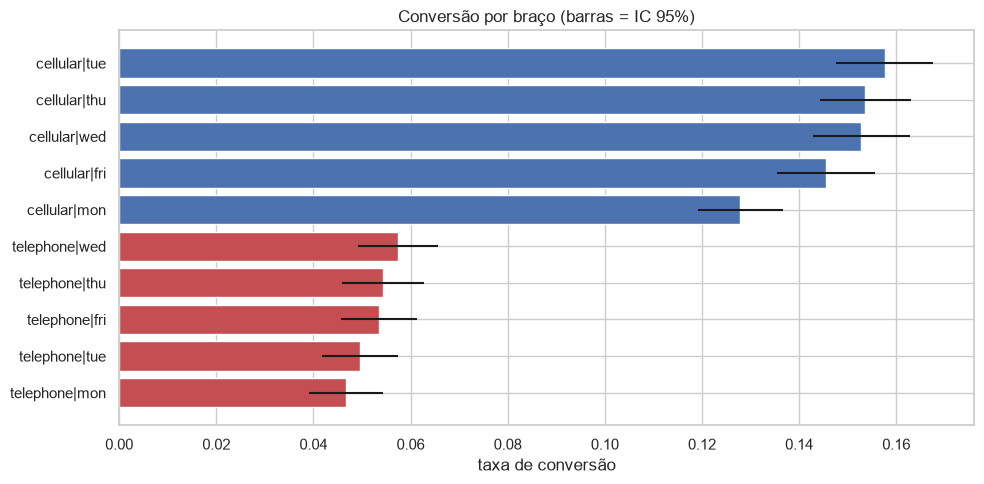

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
dados = por_braco.sort_values("taxa")
cores = ["#4C72B0" if a.startswith("cellular") else "#C44E52" for a in dados.index]
ax.barh(dados.index, dados["taxa"], xerr=1.96 * dados["erro_padrao"], color=cores)
ax.set_xlabel("taxa de conversão"); ax.set_title("Conversão por braço (barras = IC 95%)")
plt.tight_layout(); plt.show()

### Resultado central da EDA

O canal é o fator que mais influencia a conversão. No agregado, o celular
converte cerca de três vezes mais que o telefone fixo, e mesmo o braço de
celular com pior desempenho converte mais que o dobro do melhor braço de
telefone fixo. O dia da semana produz diferenças bem menores.

Esse resultado tem uma implicação que o trabalho assume de forma explícita. Como
existe uma ação dominante, uma regra fixa que escolha sempre "celular na
terça-feira" já é quase ótima. Em um ambiente estável, qualquer algoritmo que
precise testar alternativas perde para essa regra, porque gasta parte dos
contatos em opções piores. O notebook 02 mede esse custo, em vez de omiti-lo, e
apresenta as duas situações em que a política adaptativa passa a ter vantagem.

### Observação sobre interpretação causal

Os números acima indicam associação, e não causa. A instituição não sorteou o
canal de contato entre os clientes. É plausível que clientes com celular
cadastrado sejam, em média, mais jovens e mais habituados a canais digitais e,
por isso, mais propensos a converter por qualquer canal. Parte da vantagem
observada pode vir do perfil de quem tem celular cadastrado, e não do canal em
si.

Medir o efeito causal exigiria sortear o canal entre os clientes, que é
exatamente o que uma plataforma de bandit faz ao explorar alternativas.

## 5. Existe sinal contextual?

Esta é a pergunta que determina a arquitetura do projeto: o melhor braço é o
mesmo para todos os clientes? Se for, um bandit único para toda a base é
suficiente, e personalizar a decisão apenas acrescenta complexidade.

In [9]:
def taxa_por(coluna, minimo=200):
    tabela = (raw.groupby(coluna)
                 .agg(clientes=("reward", "size"), conversao=("reward", "mean"))
                 .query("clientes >= @minimo")
                 .sort_values("conversao", ascending=False))
    return tabela.style.format({"conversao": "{:.2%}"})

taxa_por("poutcome")

,clientes,conversao
poutcome,,
success,1373,65.11%
failure,4252,14.23%
nonexistent,35563,8.83%


A coluna `poutcome` registra o desfecho da campanha anterior e é o atributo mais
preditivo da base: clientes que já converteram antes voltam a converter a uma
taxa quase seis vezes maior que a média geral. É esse eixo que a segmentação
feita no notebook 02 precisa preservar.

In [10]:
taxa_por("job")

,clientes,conversao
job,,
student,875,31.43%
retired,1720,25.23%
unemployed,1014,14.20%
admin.,10422,12.97%
management,2924,11.22%
unknown,330,11.21%
technician,6743,10.83%
self-employed,1421,10.49%
housemaid,1060,10.00%


In [11]:
raw["faixa_etaria"] = pd.cut(raw["age"], [17, 25, 35, 45, 55, 65, 120],
                             labels=["18-25", "26-35", "36-45", "46-55", "56-65", "65+"])
taxa_por("faixa_etaria", minimo=100)

,clientes,conversao
faixa_etaria,,
65+,619,46.85%
18-25,1661,20.89%
56-65,2963,15.22%
26-35,14847,11.72%
46-55,8249,8.69%
36-45,12844,8.51%


A conversão tem formato de U em relação à idade. Os mais jovens, em boa parte
estudantes, e os mais velhos, em boa parte aposentados, convertem acima da
média, enquanto a faixa economicamente ativa converte abaixo dela.

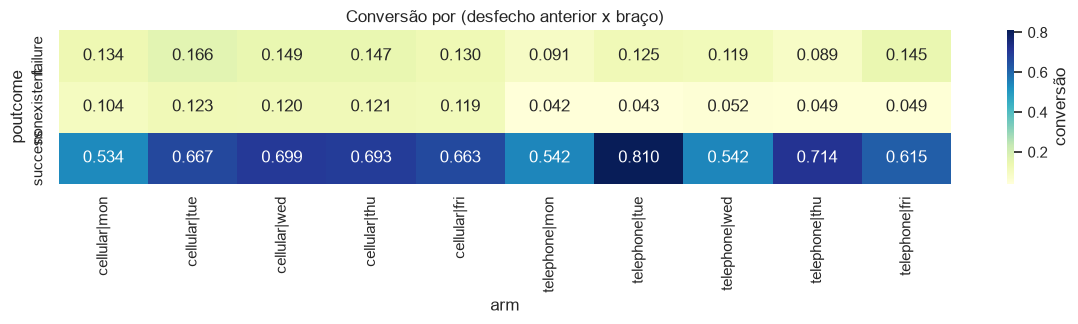

Melhor braço em cada linha:
poutcome
failure         cellular|tue
nonexistent     cellular|tue
success        telephone|tue

Suporte amostral (n) das células de telefone fixo:
arm          telephone|mon  telephone|tue  telephone|wed  telephone|thu  telephone|fri
poutcome                                                                              
failure                 66             56             67             56             55
nonexistent           2889           2906           2991           2741           3114
success                 24             21             24             21             13


In [12]:
# Verifica se o melhor braço muda conforme o histórico do cliente.
cruzamento = raw.pivot_table(index="poutcome", columns="arm", values="reward", aggfunc="mean").reindex(columns=ARMS)
suporte   = raw.pivot_table(index="poutcome", columns="arm", values="reward", aggfunc="count").reindex(columns=ARMS)

fig, ax = plt.subplots(figsize=(12, 3.4))
sns.heatmap(cruzamento, annot=True, fmt=".3f", cmap="YlGnBu", cbar_kws={"label": "conversão"}, ax=ax)
ax.set_title("Conversão por (desfecho anterior x braço)"); plt.tight_layout(); plt.show()

print("Melhor braço em cada linha:")
print(cruzamento.idxmax(axis=1).to_string())
print("\nSuporte amostral (n) das células de telefone fixo:")
print(suporte[[a for a in ARMS if a.startswith('telephone')]].to_string())

### Um resultado aparentemente forte que não se sustenta

Na linha `success`, o braço `telephone|tue` aparece com a maior taxa da tabela.
À primeira vista, isso sugeriria que o canal preferencial se inverte para
clientes que já converteram, o que seria um achado relevante.

O achado não se sustenta, porque a célula reúne pouquíssimos dados: são apenas
algumas dezenas de observações, como mostram as contagens impressas acima.
Quando os dias da semana são agrupados e somente o canal é comparado dentro
desse grupo, a diferença desaparece. A célula seguinte faz essa verificação.

In [13]:
quentes = raw[raw["poutcome"] == "success"]
agregado = (quentes.assign(canal=quentes["arm"].str.split("|").str[0])
                   .groupby("canal")["reward"].agg(eventos="count", conversao="mean"))
agregado["erro_padrao"] = np.sqrt(agregado["conversao"] * (1 - agregado["conversao"]) / agregado["eventos"])
print("Clientes que converteram na campanha anterior:")
print(agregado.round(4).to_string())

geral = (raw.assign(canal=raw["arm"].str.split("|").str[0])
            .groupby("canal")["reward"].mean())
print("\nBase inteira:")
print(geral.round(4).to_string())

Clientes que converteram na campanha anterior:
           eventos  conversao  erro_padrao
canal                                     
cellular      1270     0.6520       0.0134
telephone      103     0.6408       0.0473

Base inteira:
canal
cellular     0.1474
telephone    0.0523


### Enunciado preciso do efeito contextual

Na base inteira, o telefone fixo converte cerca de um terço do que converte o
celular. No grupo de clientes que já converteu em campanha anterior, os dois
canais não apresentam diferença estatisticamente detectável, ou seja, a
desvantagem do telefone fixo desaparece.

Não se trata, portanto, de uma inversão do melhor canal, mas da anulação de uma
desvantagem. A consequência prática é de custo, e não de conversão: para
clientes com histórico positivo, é possível usar o canal mais barato sem perda
de conversão. Por isso o ganho de conversão que a personalização pode trazer é
modesto, da ordem de 2%, valor quantificado no notebook 02.

Registrar essa correção faz parte do resultado. A taxa de 81% da célula isolada
produziria um número bem mais favorável na apresentação, mas corresponderia a
ruído amostral apresentado como descoberta.

## 6. Variáveis macroeconômicas e o motivo de sua exclusão

A base traz cinco indicadores macroeconômicos, entre eles `euribor3m`, a taxa de
juros de referência, e `nr.employed`, o número de pessoas empregadas. Eles têm
correlação alta com a conversão, mas descrevem o ambiente econômico, e não o
cliente: não é possível escolher qual taxa Euribor se aplica a um cliente
específico.

Esses indicadores poderiam entrar como contexto de ambiente, compartilhado por
todos os clientes do mesmo período, mas nunca como atributo de personalização.
Neste trabalho, permanecem fora do contexto de decisão.

In [14]:
correlacoes = raw[MACRO_COLUMNS + ["reward"]].corr()["reward"].drop("reward").sort_values()
correlacoes.to_frame("correlação com conversão").round(3)

,correlação com conversão
nr.employed,-0.355
euribor3m,-0.308
emp.var.rate,-0.298
cons.price.idx,-0.136
cons.conf.idx,0.055


## 7. Política de features: o que entra na decisão

A tabela a seguir registra a aplicação do princípio de minimização de dados,
segundo o qual só deve ser usado aquilo que é necessário para a decisão. Cada
exclusão tem motivo declarado. A mesma política está codificada em
`src/adaptive_offers/config.py`, que funciona como ponto único de governança.

In [15]:
politica = pd.DataFrame([
    ("age",            "USA",  "faixa etária tem padrão de conversão em U, bem definido"),
    ("job",            "USA",  "proxy comportamental de disponibilidade e perfil financeiro"),
    ("education",      "USA",  "correlaciona com o produto; monitorada contra viés de proxy"),
    ("housing/loan",   "USA",  "relacionamento com a instituição, não capacidade de pagamento"),
    ("campaign",       "USA",  "pressão de contato no ciclo atual — sinal de fadiga"),
    ("pdays/previous", "USA",  "recência e frequência do relacionamento"),
    ("poutcome",       "USA",  "desfecho anterior: o sinal mais forte da base"),
    ("duration",       "FORA", "vazamento temporal: só é conhecida após a ligação"),
    ("marital",        "FORA", "estado civil — sensível e sem justificativa de necessidade"),
    ("default",        "FORA", "inadimplência — sensível; decisão de crédito exige humano no loop"),
    ("macroeconômicas","FORA", "contexto ambiente, não atributo do cliente"),
    ("month",          "FORA", "sazonalidade do histórico; não é decisão por cliente"),
], columns=["variável", "decisão", "justificativa"])
politica

,variável,decisão,justificativa
0,age,USA,"faixa etária tem padrão de conversão em U, bem..."
1,job,USA,proxy comportamental de disponibilidade e perf...
2,education,USA,correlaciona com o produto; monitorada contra ...
3,housing/loan,USA,"relacionamento com a instituição, não capacida..."
4,campaign,USA,pressão de contato no ciclo atual — sinal de f...
5,pdays/previous,USA,recência e frequência do relacionamento
6,poutcome,USA,desfecho anterior: o sinal mais forte da base
7,duration,FORA,vazamento temporal: só é conhecida após a ligação
8,marital,FORA,estado civil — sensível e sem justificativa de...
9,default,FORA,inadimplência — sensível; decisão de crédito e...


In [16]:
print("Contexto final usado na decisão:")
for f in CONTEXT_FEATURES:
    print(" -", f)

Contexto final usado na decisão:
 - age
 - campaign
 - previous
 - previously_contacted
 - recency_score
 - job
 - education
 - housing
 - loan
 - poutcome


## 8. Conclusões da Etapa 1

1. A base é adequada ao desafio: 41.176 eventos após a remoção de duplicatas,
   com conversão real registrada, o que dispensa a geração de dados sintéticos.
2. A coluna `duration` configura vazamento temporal e foi descartada. Essa
   decisão reduz as métricas aparentes e é a única defensável.
3. O espaço de ações é a combinação (canal, dia), com 10 braços, todos com
   milhares de observações.
4. Existe uma ação dominante, o celular, o que torna a regra fixa um baseline
   forte. O trabalho mede esse fato, em vez de escolher um baseline fraco.
5. O sinal contextual real é modesto e diz respeito a custo: no grupo de
   clientes com histórico positivo, a desvantagem do telefone fixo desaparece.
6. A coluna `poutcome` é o eixo de segmentação e precisa ser preservada na
   clusterização. O notebook 02 mostra que isso exige padronizar as colunas
   one-hot, sem o que o sinal se dilui.

A continuação está em `02_baseline_e_bandits.ipynb`.